In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.model_selection import learning_curve, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import joblib
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load splits
X_train = pd.read_csv(r'..\Data\Splits\X_train.csv')
y_train = pd.read_csv(r'..\Data\Splits\y_train.csv').squeeze().values
X_test  = pd.read_csv(r'..\Data\Splits\X_test.csv')
y_test  = pd.read_csv(r'..\Data\Splits\y_test.csv').squeeze().values

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:", pd.Series(y_train).value_counts().to_dict())
print("Test class distribution:", pd.Series(y_test).value_counts().to_dict())

Train shape: (12800, 8) Test shape: (2001, 8)
Train class distribution: {1: 6400, 0: 6400}
Test class distribution: {0: 1600, 1: 401}


In [13]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5)
}

results = {}

def train_evaluate(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    y_test_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Train Accuracy": accuracy_score(y_tr, y_train_pred),
        "Test Accuracy": accuracy_score(y_te, y_test_pred),
        "Test Precision": precision_score(y_te, y_test_pred),
        "Test Recall": recall_score(y_te, y_test_pred),
        "Test F1": f1_score(y_te, y_test_pred),
        "Test ROC AUC": roc_auc_score(y_te, y_test_proba) if y_test_proba is not None else None,
        "Train Time (s)": train_time
    }
    return metrics, model, y_test_pred, y_test_proba

In [14]:
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"Training {name}...")
    metrics, trained_model, preds, proba = train_evaluate(name, model, X_train, y_train, X_test, y_test)
    results[name] = metrics
    trained_models[name] = trained_model
    predictions[name] = preds
    probabilities[name] = proba
    print(f"  Test F1: {metrics['Test F1']:.4f} | ROC AUC: {metrics['Test ROC AUC']:.4f} | Time: {metrics['Train Time (s)']:.2f}s\n")

Training Logistic Regression...
  Test F1: 0.6552 | ROC AUC: 0.9332 | Time: 0.03s

Training Decision Tree...
  Test F1: 0.9429 | ROC AUC: 0.9732 | Time: 0.03s

Training Random Forest...
  Test F1: 0.9495 | ROC AUC: 0.9954 | Time: 0.27s

Training XGBoost...
  Test F1: 0.9518 | ROC AUC: 0.9972 | Time: 0.10s

Training K-Nearest Neighbours...


C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\Private\TrafficSense AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:26:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Test F1: 0.8620 | ROC AUC: 0.9799 | Time: 0.02s



In [15]:
results_df = pd.DataFrame(results).T
print("=== MODEL COMPARISON (Test Set) ===")
print(results_df.round(4).to_string())

=== MODEL COMPARISON (Test Set) ===
                      Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC AUC  Train Time (s)
Logistic Regression           0.8576         0.8001          0.5007       0.9476   0.6552        0.9332          0.0293
Decision Tree                 1.0000         0.9765          0.9194       0.9676   0.9429        0.9732          0.0274
Random Forest                 1.0000         0.9790          0.9165       0.9850   0.9495        0.9954          0.2734
XGBoost                       0.9978         0.9800          0.9207       0.9850   0.9518        0.9972          0.0969
K-Nearest Neighbours          0.9746         0.9395          0.7941       0.9426   0.8620        0.9799          0.0188


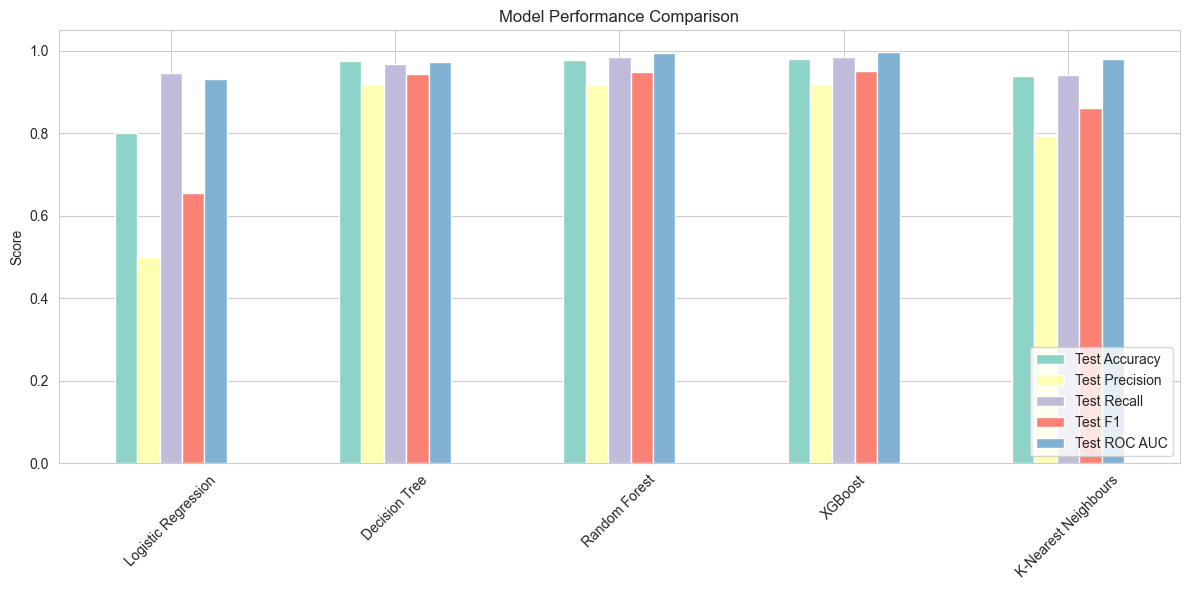

In [16]:
metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

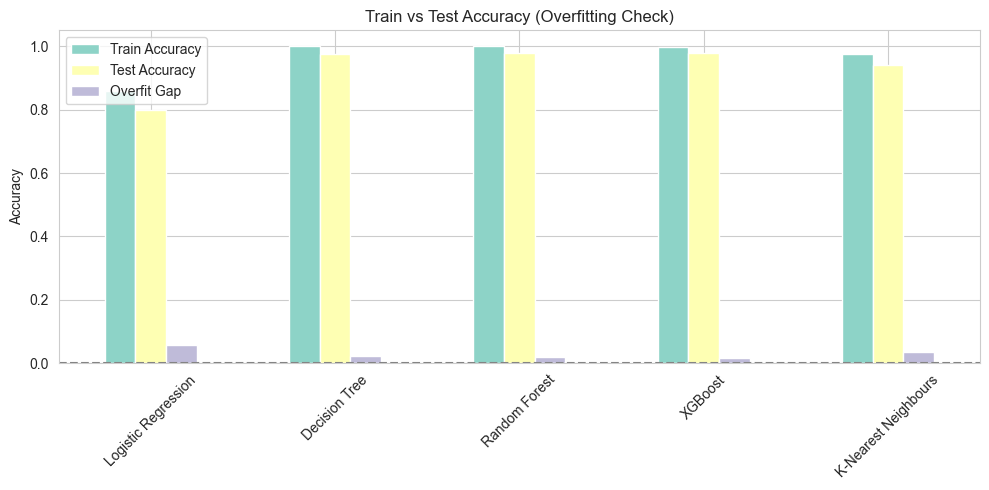

Overfit Gap (Train - Test):
Logistic Regression     0.0575
Decision Tree           0.0235
Random Forest           0.0210
XGBoost                 0.0178
K-Nearest Neighbours    0.0351
Name: Overfit Gap, dtype: float64


In [17]:
overfit_df = results_df[['Train Accuracy', 'Test Accuracy']].copy()
overfit_df['Overfit Gap'] = overfit_df['Train Accuracy'] - overfit_df['Test Accuracy']

overfit_df.plot(kind='bar', figsize=(10,5))
plt.title('Train vs Test Accuracy (Overfitting Check)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

print("Overfit Gap (Train - Test):")
print(overfit_df['Overfit Gap'].round(4))

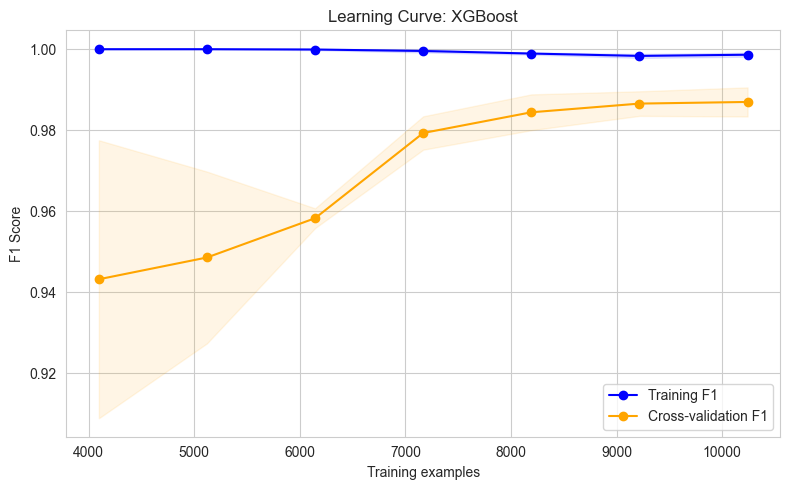

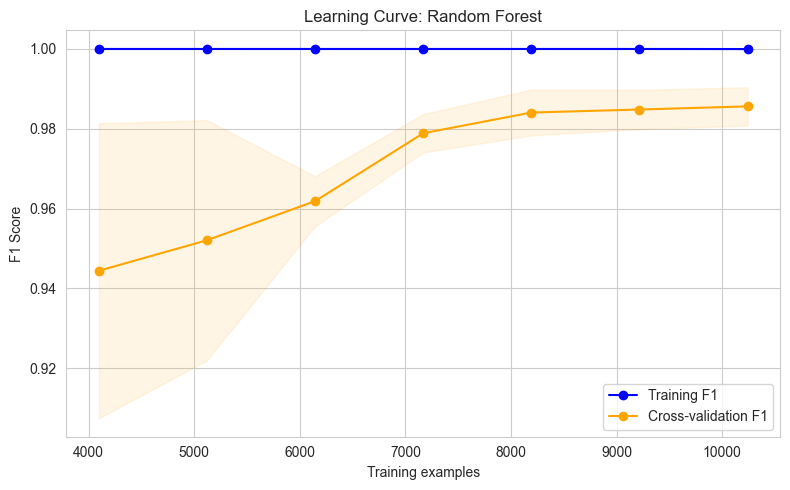

In [18]:
def plot_learning_curve(model, X, y, model_name, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation F1')
    plt.title(f'Learning Curve: {model_name}')
    plt.xlabel('Training examples')
    plt.ylabel('F1 Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for best two models (XGBoost and Random Forest)
plot_learning_curve(trained_models["XGBoost"], X_train, y_train, "XGBoost")
plot_learning_curve(trained_models["Random Forest"], X_train, y_train, "Random Forest")

C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\Private\TrafficSense AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:26:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


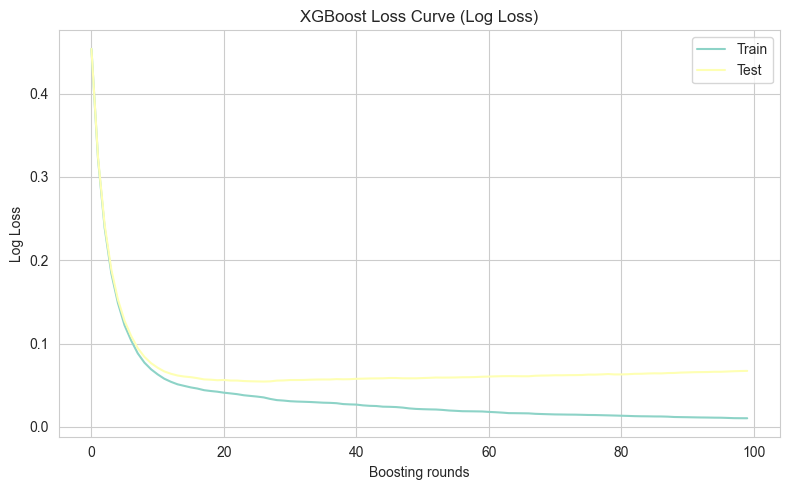

In [19]:
# Re‑train XGBoost with eval set to get loss history
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

results_xgb = xgb_model.evals_result()
epochs = len(results_xgb['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(8,5))
plt.plot(x_axis, results_xgb['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results_xgb['validation_1']['logloss'], label='Test')
plt.title('XGBoost Loss Curve (Log Loss)')
plt.xlabel('Boosting rounds')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

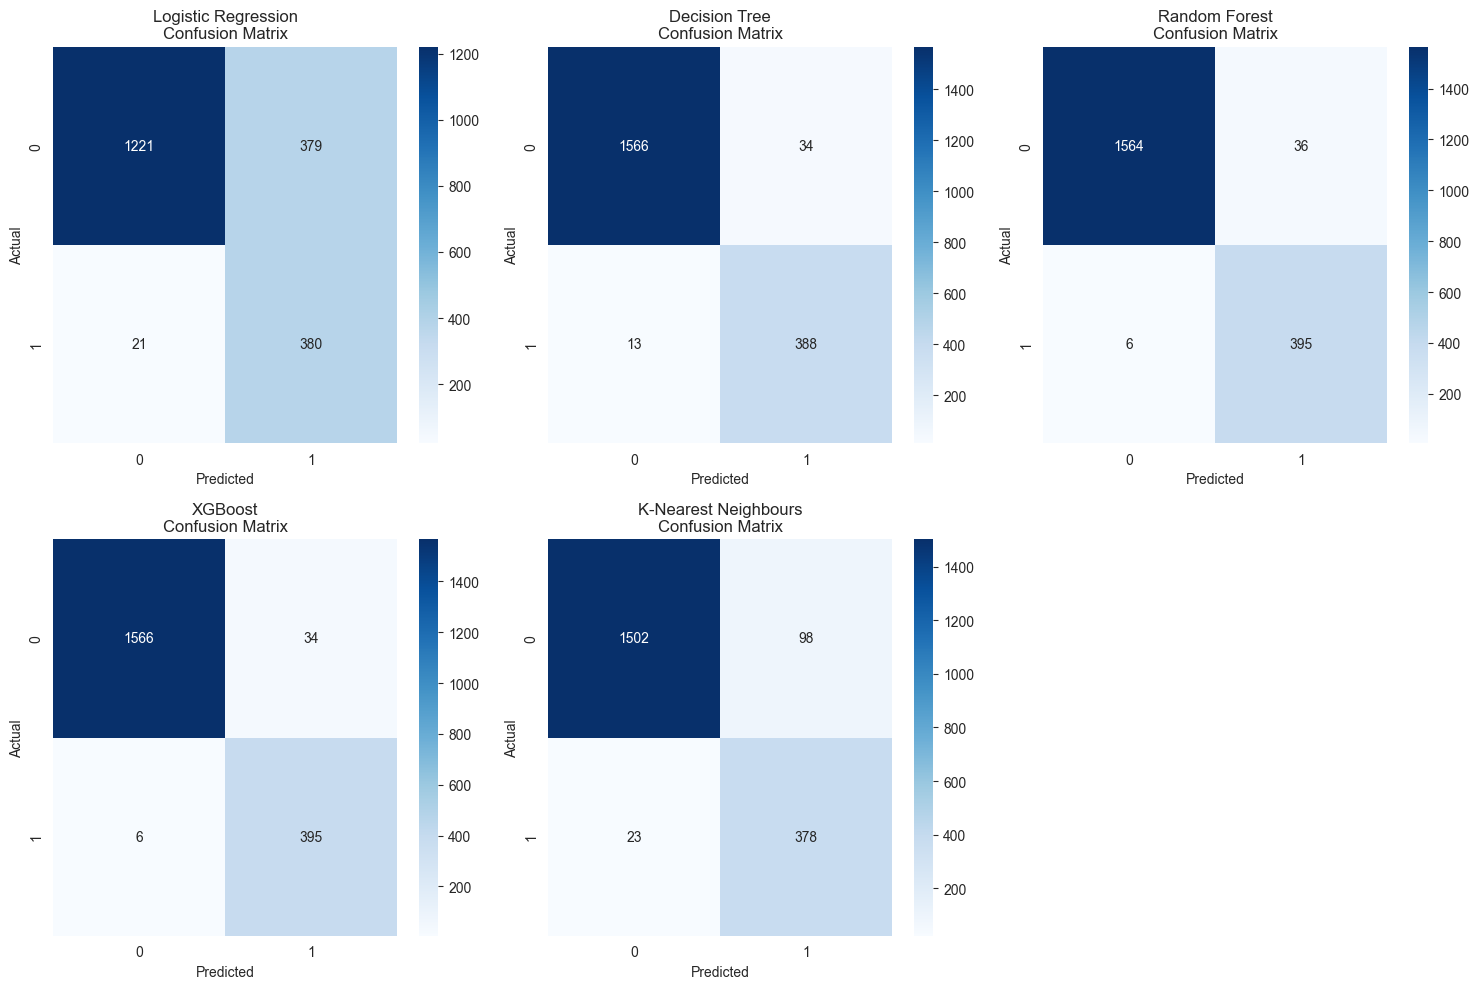


Model: Logistic Regression
Confusion Matrix:
[[1221  379]
 [  21  380]]

Detailed Breakdown:
True Negatives (TN): 1221
False Positives (FP): 379
False Negatives (FN): 21
True Positives (TP): 380
--------------------------------------------------

Model: Decision Tree
Confusion Matrix:
[[1566   34]
 [  13  388]]

Detailed Breakdown:
True Negatives (TN): 1566
False Positives (FP): 34
False Negatives (FN): 13
True Positives (TP): 388
--------------------------------------------------

Model: Random Forest
Confusion Matrix:
[[1564   36]
 [   6  395]]

Detailed Breakdown:
True Negatives (TN): 1564
False Positives (FP): 36
False Negatives (FN): 6
True Positives (TP): 395
--------------------------------------------------

Model: XGBoost
Confusion Matrix:
[[1566   34]
 [   6  395]]

Detailed Breakdown:
True Negatives (TN): 1566
False Positives (FP): 34
False Negatives (FN): 6
True Positives (TP): 395
--------------------------------------------------

Model: K-Nearest Neighbours
Confusion Ma

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide any unused subplot
for i in range(len(models), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()
from sklearn.metrics import confusion_matrix

for name, preds in predictions.items():
    cm = confusion_matrix(y_test, preds)

    tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*50)
    print(f"Model: {name}")
    print("="*50)

    print("Confusion Matrix:")
    print(cm)

    print("\nDetailed Breakdown:")
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

    print("-"*50)

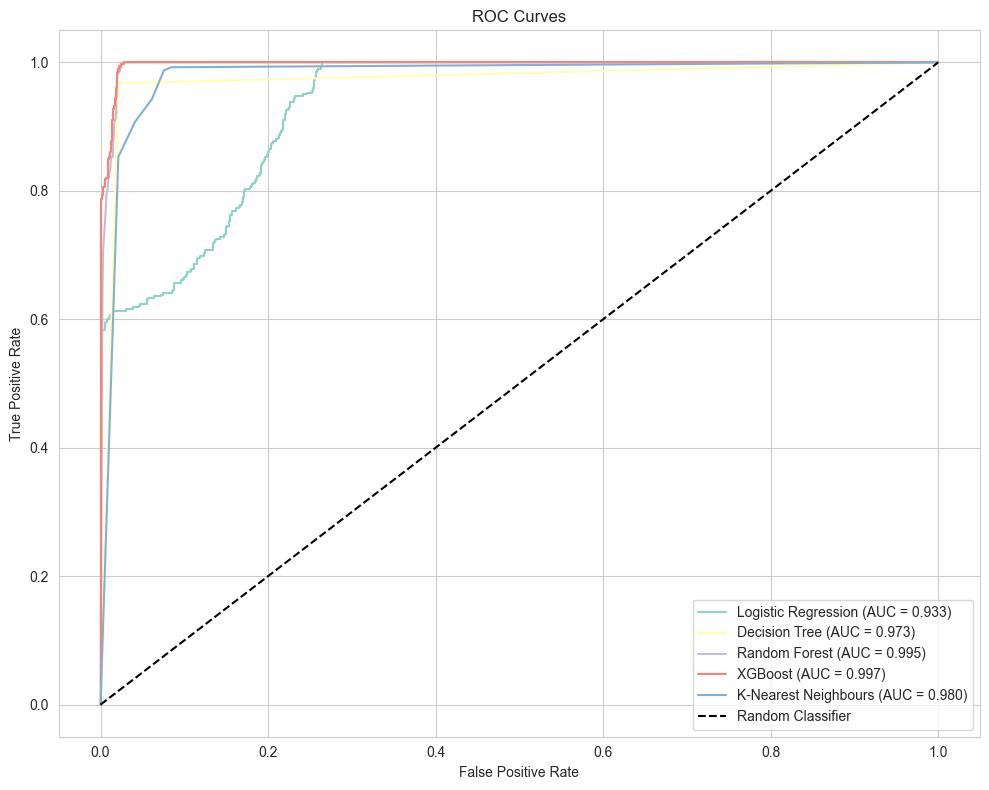

In [21]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))
for name, proba in probabilities.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = results[name]['Test ROC AUC']
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
best_model = results_df['Test F1'].idxmax()
best_f1 = results_df.loc[best_model, 'Test F1']
best_auc = results_df.loc[best_model, 'Test ROC AUC']

print(f"🏆 Best model based on Test F1: {best_model}")
print(f"   F1 Score: {best_f1:.4f} | ROC AUC: {best_auc:.4f}")
print("\nOverfitting assessment:")
for name in results_df.index:
    gap = results_df.loc[name, 'Train Accuracy'] - results_df.loc[name, 'Test Accuracy']
    status = "Likely overfitting" if gap > 0.05 else "Generalises well"
    print(f"  {name:20s} : gap = {gap:.4f} → {status}")



🏆 Best model based on Test F1: XGBoost
   F1 Score: 0.9518 | ROC AUC: 0.9972

Overfitting assessment:
  Logistic Regression  : gap = 0.0575 → Likely overfitting
  Decision Tree        : gap = 0.0235 → Generalises well
  Random Forest        : gap = 0.0210 → Generalises well
  XGBoost              : gap = 0.0178 → Generalises well
  K-Nearest Neighbours : gap = 0.0351 → Generalises well


In [24]:
import joblib
import os

# Create directory for baseline models
os.makedirs(r'..\Models\Baseline_Models', exist_ok=True)

# Save each trained baseline model
for name, model in trained_models.items():
    # Create a safe filename (replace spaces with underscores)
    filename = name.replace(' ', '_') + '.pkl'
    filepath = os.path.join(r'..\Models\Baseline_Models', filename)
    joblib.dump(model, filepath)
    print(f"✅ Saved {name} → {filepath}")

print("\nAll baseline models saved.")

✅ Saved Logistic Regression → ..\Models\Baseline_Models\Logistic_Regression.pkl
✅ Saved Decision Tree → ..\Models\Baseline_Models\Decision_Tree.pkl
✅ Saved Random Forest → ..\Models\Baseline_Models\Random_Forest.pkl
✅ Saved XGBoost → ..\Models\Baseline_Models\XGBoost.pkl
✅ Saved K-Nearest Neighbours → ..\Models\Baseline_Models\K-Nearest_Neighbours.pkl

All baseline models saved.
